In [1]:
import os
import pandas as pd
import numpy as np
import time

from statsmodels.tsa.stattools import grangercausalitytests
from statsmodels.tsa.api import VAR
from sklearn.model_selection import learning_curve
import shap

import traceback
import psutil as ps
import warnings
warnings.filterwarnings("ignore")

In [2]:
%run "C:/Users/KISHORE/OneDrive/Desktop/Intelligent Weather Prediction Pipeline/src/models/train_models.py"
%run "C:/Users/KISHORE/OneDrive/Desktop/Intelligent Weather Prediction Pipeline/src/models/fine_tune_models.py"

In [3]:
os.chdir("C:/Users/KISHORE/OneDrive/Desktop/Intelligent Weather Prediction Pipeline")
from src.models import train_models
from src.models import fine_tune_models

In [4]:
os.chdir("C:/Users/KISHORE/OneDrive/Desktop/Intelligent Weather Prediction Pipeline/data/processed")
weather_data = pd.read_csv("clean_weather_data.csv", parse_dates = ["Date"])
weather_data.head()

,Date,Temperature,Relative_humidity,Rain,Soil_temperature,Wind_speed,Surface_pressure,Pressure_msl,is_day,Rolling Mean of Temperature,...,Rolling std of Surface_pressure,Rolling std of Pressure_msl,Day_of-year,Sine_Day_of-year,Cose_Day_of-year,day_of_week,day_of_month,month,quarter,is_weekend
0,2020-01-01 23:00:00,10.3,95,0.0,11.7,17.0,1007.0,1021.7,0,11.629167,...,1.337252,1.297482,1,0.017213,0.999852,2,1,1,1,0
1,2020-01-02 00:00:00,10.8,94,0.0,11.4,20.0,1006.7,1021.3,0,11.837500,...,1.299770,1.275948,2,0.034422,0.999407,3,2,1,1,0
2,2020-01-02 01:00:00,10.4,95,0.0,11.2,18.4,1006.3,1020.9,0,12.033333,...,1.244437,1.239536,2,0.034422,0.999407,3,2,1,1,0
3,2020-01-02 02:00:00,10.3,95,0.0,11.0,18.9,1006.2,1020.8,0,12.212500,...,1.194523,1.203618,2,0.034422,0.999407,3,2,1,1,0
4,2020-01-02 03:00:00,9.8,96,0.0,10.8,18.1,1005.6,1020.3,0,12.379167,...,1.148913,1.175351,2,0.034422,0.999407,3,2,1,1,0


In [5]:
weather_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52585 entries, 0 to 52584
Data columns (total 31 columns):
 #   Column                             Non-Null Count  Dtype         
---  ------                             --------------  -----         
 0   Date                               52585 non-null  datetime64[ns]
 1   Temperature                        52585 non-null  float64       
 2   Relative_humidity                  52585 non-null  int64         
 3   Rain                               52585 non-null  float64       
 4   Soil_temperature                   52585 non-null  float64       
 5   Wind_speed                         52585 non-null  float64       
 6   Surface_pressure                   52585 non-null  float64       
 7   Pressure_msl                       52585 non-null  float64       
 8   is_day                             52585 non-null  int64         
 9   Rolling Mean of Temperature        52585 non-null  float64       
 10  Rolling Mean of Relative_humidity 

In [6]:
weather_data.set_index("Date",inplace = True)

In [7]:
rm_cols = [col for col in weather_data.columns if "std" or "is_" in col]
weather_data.drop(columns=rm_cols)

""
Date
2020-01-01 23:00:00
2020-01-02 00:00:00
2020-01-02 01:00:00
2020-01-02 02:00:00
2020-01-02 03:00:00
...
2025-12-31 19:00:00
2025-12-31 20:00:00
2025-12-31 21:00:00


In [8]:
weather_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 52585 entries, 2020-01-01 23:00:00 to 2025-12-31 23:00:00
Data columns (total 30 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Temperature                        52585 non-null  float64
 1   Relative_humidity                  52585 non-null  int64  
 2   Rain                               52585 non-null  float64
 3   Soil_temperature                   52585 non-null  float64
 4   Wind_speed                         52585 non-null  float64
 5   Surface_pressure                   52585 non-null  float64
 6   Pressure_msl                       52585 non-null  float64
 7   is_day                             52585 non-null  int64  
 8   Rolling Mean of Temperature        52585 non-null  float64
 9   Rolling Mean of Relative_humidity  52585 non-null  float64
 10  Rolling Mean of Rain               52585 non-null  float64
 11  Rolling Mean of Soi

In [9]:
def causality_test(data):
    max_lag = 24
    
    result = grangercausalitytests(data, maxlag = max_lag, verbose = True)
    for lag in range(1, max_lag+1):
        p_value = result[lag][0]["ssr_ftest"][1]
        print(f"lag {lag : 2d}: P Value = {p_value : .5f}")
        
    alpha = 0.05

    for lag in range(1, max_lag + 1):
        p_value = result[lag][0]['ssr_ftest'][1]

        if p_value < alpha:
            print(f"Lag {lag}: Significant (p = {p_value:.5f})")
        else:
            print(f"Lag {lag}: Not Significant (p = {p_value:.5f})")

In [10]:
causality_test(weather_data[["Temperature", "Relative_humidity"]])


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=651.9582, p=0.0000  , df_denom=52581, df_num=1
ssr based chi2 test:   chi2=651.9953, p=0.0000  , df=1
likelihood ratio test: chi2=647.9864, p=0.0000  , df=1
parameter F test:         F=651.9582, p=0.0000  , df_denom=52581, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=810.3506, p=0.0000  , df_denom=52578, df_num=2
ssr based chi2 test:   chi2=1620.8553, p=0.0000  , df=2
likelihood ratio test: chi2=1596.3758, p=0.0000  , df=2
parameter F test:         F=810.3506, p=0.0000  , df_denom=52578, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=837.2655, p=0.0000  , df_denom=52575, df_num=3
ssr based chi2 test:   chi2=2512.1309, p=0.0000  , df=3
likelihood ratio test: chi2=2453.9671, p=0.0000  , df=3
parameter F test:         F=837.2655, p=0.0000  , df_denom=52575, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=648.

In [11]:
causality_test(weather_data[["Temperature", "Rain"]])


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=1.3417  , p=0.2467  , df_denom=52581, df_num=1
ssr based chi2 test:   chi2=1.3418  , p=0.2467  , df=1
likelihood ratio test: chi2=1.3418  , p=0.2467  , df=1
parameter F test:         F=1.3417  , p=0.2467  , df_denom=52581, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=327.0312, p=0.0000  , df_denom=52578, df_num=2
ssr based chi2 test:   chi2=654.1246, p=0.0000  , df=2
likelihood ratio test: chi2=650.0894, p=0.0000  , df=2
parameter F test:         F=327.0312, p=0.0000  , df_denom=52578, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=196.6525, p=0.0000  , df_denom=52575, df_num=3
ssr based chi2 test:   chi2=590.0361, p=0.0000  , df=3
likelihood ratio test: chi2=586.7502, p=0.0000  , df=3
parameter F test:         F=196.6525, p=0.0000  , df_denom=52575, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=150.2150

In [12]:
causality_test(weather_data[["Temperature", "Soil_temperature"]])


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=4113.0903, p=0.0000  , df_denom=52581, df_num=1
ssr based chi2 test:   chi2=4113.3250, p=0.0000  , df=1
likelihood ratio test: chi2=3960.3714, p=0.0000  , df=1
parameter F test:         F=4113.0903, p=0.0000  , df_denom=52581, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=2277.8607, p=0.0000  , df_denom=52578, df_num=2
ssr based chi2 test:   chi2=4556.1547, p=0.0000  , df=2
likelihood ratio test: chi2=4369.4754, p=0.0000  , df=2
parameter F test:         F=2277.8607, p=0.0000  , df_denom=52578, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=1707.8438, p=0.0000  , df_denom=52575, df_num=3
ssr based chi2 test:   chi2=5124.2136, p=0.0000  , df=3
likelihood ratio test: chi2=4889.6528, p=0.0000  , df=3
parameter F test:         F=1707.8438, p=0.0000  , df_denom=52575, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:       

In [13]:
causality_test(weather_data[["Temperature", "Wind_speed"]])


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=733.2341, p=0.0000  , df_denom=52581, df_num=1
ssr based chi2 test:   chi2=733.2759, p=0.0000  , df=1
likelihood ratio test: chi2=728.2102, p=0.0000  , df=1
parameter F test:         F=733.2341, p=0.0000  , df_denom=52581, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=18.6406 , p=0.0000  , df_denom=52578, df_num=2
ssr based chi2 test:   chi2=37.2848 , p=0.0000  , df=2
likelihood ratio test: chi2=37.2716 , p=0.0000  , df=2
parameter F test:         F=18.6406 , p=0.0000  , df_denom=52578, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=41.6232 , p=0.0000  , df_denom=52575, df_num=3
ssr based chi2 test:   chi2=124.8861, p=0.0000  , df=3
likelihood ratio test: chi2=124.7380, p=0.0000  , df=3
parameter F test:         F=41.6232 , p=0.0000  , df_denom=52575, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=58.5481 

In [14]:
causality_test(weather_data[["Temperature", "Surface_pressure"]])


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=498.8146, p=0.0000  , df_denom=52581, df_num=1
ssr based chi2 test:   chi2=498.8430, p=0.0000  , df=1
likelihood ratio test: chi2=496.4917, p=0.0000  , df=1
parameter F test:         F=498.8146, p=0.0000  , df_denom=52581, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=1935.0945, p=0.0000  , df_denom=52578, df_num=2
ssr based chi2 test:   chi2=3870.5570, p=0.0000  , df=2
likelihood ratio test: chi2=3734.7300, p=0.0000  , df=2
parameter F test:         F=1935.0945, p=0.0000  , df_denom=52578, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=2283.0021, p=0.0000  , df_denom=52575, df_num=3
ssr based chi2 test:   chi2=6849.9182, p=0.0000  , df=3
likelihood ratio test: chi2=6439.0639, p=0.0000  , df=3
parameter F test:         F=2283.0021, p=0.0000  , df_denom=52575, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=

In [15]:
causality_test(weather_data[["Temperature", "Pressure_msl"]])


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=498.2695, p=0.0000  , df_denom=52581, df_num=1
ssr based chi2 test:   chi2=498.2979, p=0.0000  , df=1
likelihood ratio test: chi2=495.9517, p=0.0000  , df=1
parameter F test:         F=498.2695, p=0.0000  , df_denom=52581, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=1944.1009, p=0.0000  , df_denom=52578, df_num=2
ssr based chi2 test:   chi2=3888.5716, p=0.0000  , df=2
likelihood ratio test: chi2=3751.5068, p=0.0000  , df=2
parameter F test:         F=1944.1009, p=0.0000  , df_denom=52578, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=2283.8195, p=0.0000  , df_denom=52575, df_num=3
ssr based chi2 test:   chi2=6852.3707, p=0.0000  , df=3
likelihood ratio test: chi2=6441.2337, p=0.0000  , df=3
parameter F test:         F=2283.8195, p=0.0000  , df_denom=52575, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=

In [16]:
weather_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 52585 entries, 2020-01-01 23:00:00 to 2025-12-31 23:00:00
Data columns (total 30 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Temperature                        52585 non-null  float64
 1   Relative_humidity                  52585 non-null  int64  
 2   Rain                               52585 non-null  float64
 3   Soil_temperature                   52585 non-null  float64
 4   Wind_speed                         52585 non-null  float64
 5   Surface_pressure                   52585 non-null  float64
 6   Pressure_msl                       52585 non-null  float64
 7   is_day                             52585 non-null  int64  
 8   Rolling Mean of Temperature        52585 non-null  float64
 9   Rolling Mean of Relative_humidity  52585 non-null  float64
 10  Rolling Mean of Rain               52585 non-null  float64
 11  Rolling Mean of Soi

In [17]:
weather_data_ = weather_data.loc[:,"Temperature":"is_day"]
train_data = weather_data_[:int(0.9*len(weather_data_))]
test_data = weather_data_[int(0.9*len(weather_data_)):]

In [18]:
train_data.shape

(47326, 8)

In [19]:
test_data.shape

(5259, 8)

In [20]:
var_model = VAR(train_data)

In [21]:
lag_order = var_model.select_order(maxlags = 20)
lag_order.summary()

,AIC,BIC,FPE,HQIC
0,7.864,7.865,2602.,7.864
1,-8.826,-8.813,0.0001469,-8.822
2,-10.53,-10.51,2.664e-05,-10.53
3,-10.84,-10.80,1.962e-05,-10.83
4,-11.06,-11.01,1.579e-05,-11.04
5,-11.23,-11.17,1.321e-05,-11.22
6,-11.37,-11.30,1.150e-05,-11.35
7,-11.48,-11.40,1.031e-05,-11.46
8,-11.56,-11.47,9.499e-06,-11.53
9,-11.65,-11.54,8.708e-06,-11.62


In [22]:
model_result = var_model.fit(maxlags = 20)
model_result.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 11, Jul, 2026
Time:                     21:10:55
--------------------------------------------------------------------
No. of Equations:         8.00000    BIC:                   -12.3920
Nobs:                     47306.0    HQIC:                  -12.5557
Log likelihood:          -236953.    FPE:                3.27020e-06
AIC:                     -12.6307    Det(Omega_mle):     3.18251e-06
--------------------------------------------------------------------
Results for equation Temperature
                           coefficient       std. error           t-stat            prob
----------------------------------------------------------------------------------------
const                        10.371636         1.461496            7.097           0.000
L1.Temperature                1.020109         0.008816          115.710           0.000
L1.Relative_humidity  

In [23]:
forecast = model_result.forecast(
    y=train_data.values[-20:],
    steps=len(test_data)
)

In [24]:
forecast_df = pd.DataFrame(
    forecast,
    index=test_data.index,
    columns=test_data.columns
)

forecast_df.head(5)

,Temperature,Relative_humidity,Rain,Soil_temperature,Wind_speed,Surface_pressure,Pressure_msl,is_day
Date,,,,,,,,
2025-05-26 21:00:00,30.989957,60.868927,0.039925,31.962393,21.370416,986.383135,999.743255,0.053371
2025-05-26 22:00:00,30.572908,63.019008,0.024335,31.474442,21.490600,986.659061,1000.044432,-0.025645
2025-05-26 23:00:00,30.212820,65.135496,0.092775,31.079140,21.175414,986.690990,1000.094449,-0.065030
2025-05-27 00:00:00,29.754857,67.349042,0.237442,30.745525,21.181963,986.473826,999.898037,-0.054817
2025-05-27 01:00:00,29.188763,69.615661,0.253232,30.431224,21.402449,986.092352,999.543387,-0.101442


In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(
    test_data["Temperature"],
    forecast_df["Temperature"]
)

rmse = np.sqrt(
    mean_squared_error(
        test_data["Temperature"],
        forecast_df["Temperature"]
    )
)

r2 = r2_score(
    test_data["Temperature"],
    forecast_df["Temperature"]
)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 4.034843584316283
RMSE: 5.957982782263815
R²  : 0.18366943047934914


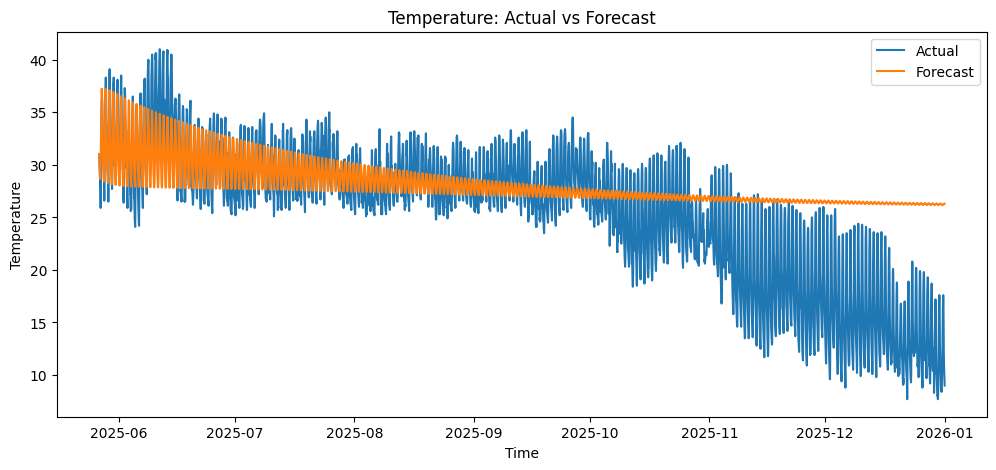

In [26]:
import matplotlib.pyplot as plt

feature = "Temperature"

plt.figure(figsize=(12, 5))

plt.plot(test_data.index, test_data[feature], label="Actual")
plt.plot(test_data.index, forecast_df[feature], label="Forecast")

plt.title(f"{feature}: Actual vs Forecast")
plt.xlabel("Time")
plt.ylabel(feature)
plt.legend()

plt.show()

In [27]:
weather_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 52585 entries, 2020-01-01 23:00:00 to 2025-12-31 23:00:00
Data columns (total 30 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Temperature                        52585 non-null  float64
 1   Relative_humidity                  52585 non-null  int64  
 2   Rain                               52585 non-null  float64
 3   Soil_temperature                   52585 non-null  float64
 4   Wind_speed                         52585 non-null  float64
 5   Surface_pressure                   52585 non-null  float64
 6   Pressure_msl                       52585 non-null  float64
 7   is_day                             52585 non-null  int64  
 8   Rolling Mean of Temperature        52585 non-null  float64
 9   Rolling Mean of Relative_humidity  52585 non-null  float64
 10  Rolling Mean of Rain               52585 non-null  float64
 11  Rolling Mean of Soi

In [28]:
train_data = weather_data[:int(0.9*len(weather_data))]
test_data = weather_data[int(0.9*len(weather_data)):]

In [29]:
train_data.shape

(47326, 30)

In [30]:
test_data.shape

(5259, 30)

In [31]:
results = train_models.xgbmodel(weather_data,train_data,test_data)

In [32]:
results

,Target,MAE,RMSE,R²,Filename
0,Temperature,0.527159,0.701469,0.988684,Temperature_xgb_model.pkl
1,Relative_humidity,2.826380,3.735067,0.952381,Relative_humidity_xgb_model.pkl
2,Rain,0.267986,0.753356,0.029953,Rain_xgb_model.pkl
3,Soil_temperature,0.486246,0.636077,0.989326,Soil_temperature_xgb_model.pkl
4,Wind_speed,3.310978,4.208739,0.600560,Wind_speed_xgb_model.pkl
5,Surface_pressure,0.028385,0.082240,0.999867,Surface_pressure_xgb_model.pkl
6,Pressure_msl,0.028520,0.081497,0.999881,Pressure_msl_xgb_model.pkl
7,is_day,0.208402,0.298260,0.644038,is_day_xgb_model.pkl


In [33]:
#fine_tune_models.finetune_model(weather_data,train_data,test_data)

In [34]:
def evaluate_model(target):
    
    X_train = train_data.drop(columns=[target])
    y_train = train_data[target]

    X_test = test_data.drop(columns=[target])
    y_test = test_data[target]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    with open(f'fine_{target}_xgb_model.pkl', 'rb') as file:
        loaded_model = pickle.load(file)

    y_pred = loaded_model.predict(X_test_scaled)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    

    return y_pred,y_test,mae,rmse,r2,loaded_model,X_train,target,X_test



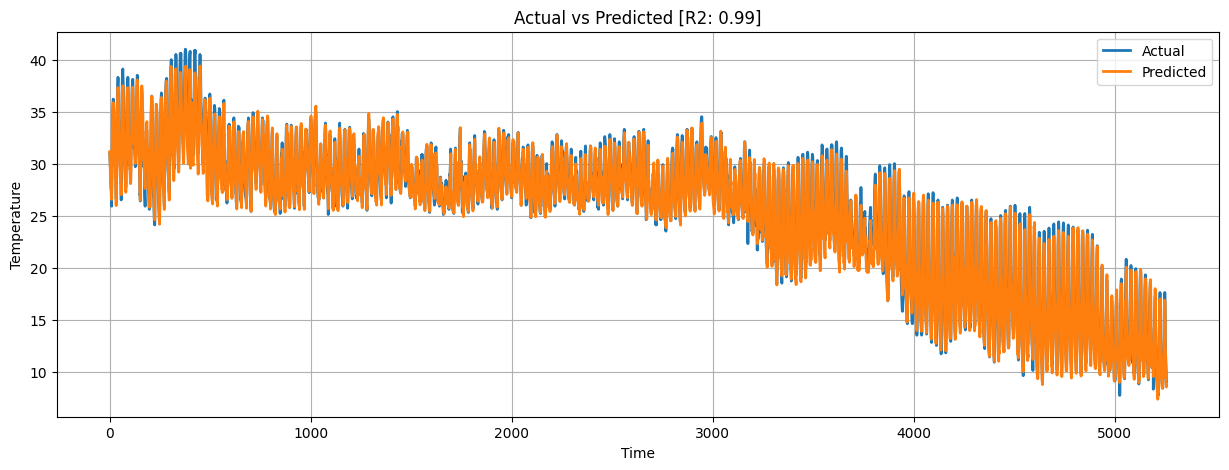

In [35]:
os.chdir("C:/Users/KISHORE/OneDrive/Desktop/Intelligent Weather Prediction Pipeline/models")
y_pred,y_test,mae,rmse,r2,model,X_train,target,X_test = evaluate_model("Temperature")

plt.figure(figsize=(15,5))
plt.plot(y_test.values, label="Actual", linewidth=2)
plt.plot(y_pred, label="Predicted", linewidth=2)
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.title(f"Actual vs Predicted [R2: {round(r2,2)}]")
plt.legend()
plt.grid(True)
plt.show()

In [36]:
params = pd.DataFrame([model.get_params()])

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
})

eval_df = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R2"],
    "Value": [mae, rmse, r2]
})

merged = pd.concat([params, importance, eval_df], ignore_index=True)

os.chdir("C:/Users/KISHORE/OneDrive/Desktop/Intelligent Weather Prediction Pipeline/models/model_summaries")
merged.to_excel(f"{target} Model Summary.xlsx",index = False)

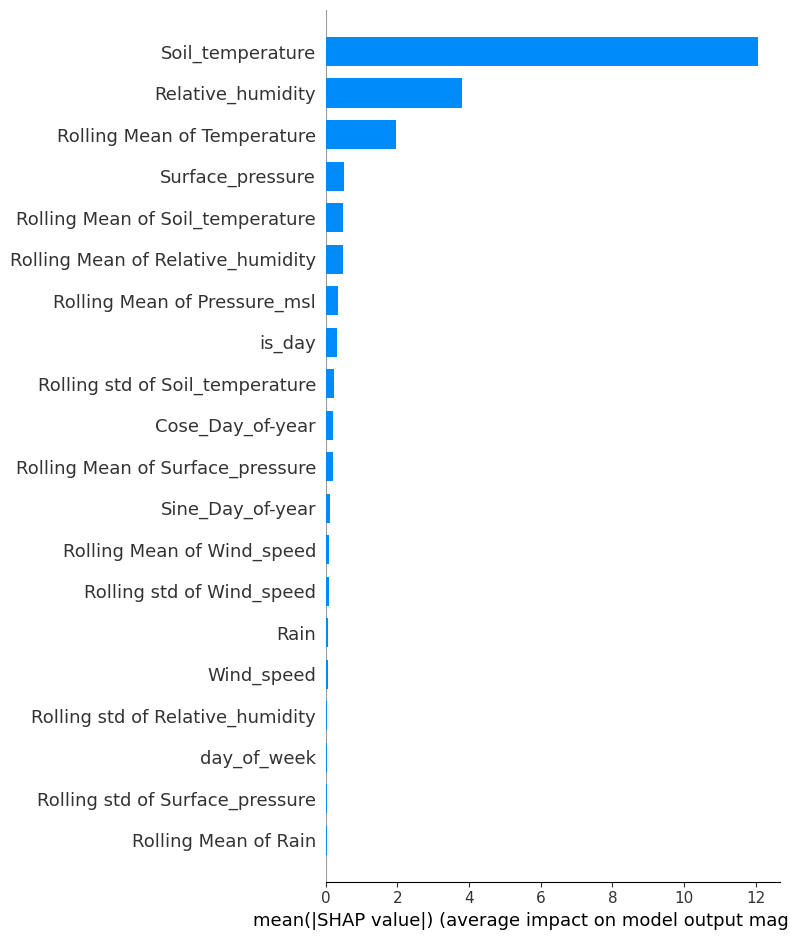

In [37]:
explainer = shap.Explainer(model)
shap_values = explainer(X_test)

shap.summary_plot(shap_values,X_test,plot_type = "bar")

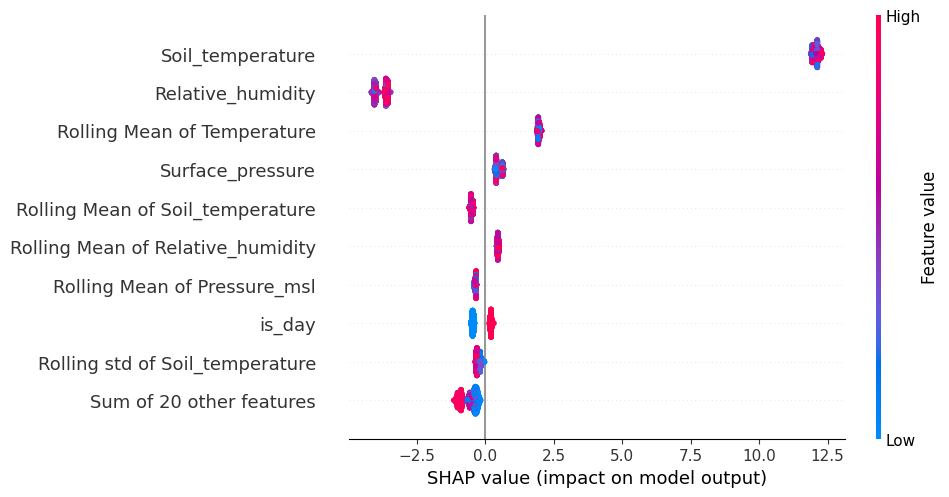

In [38]:
shap.plots.beeswarm(shap_values)

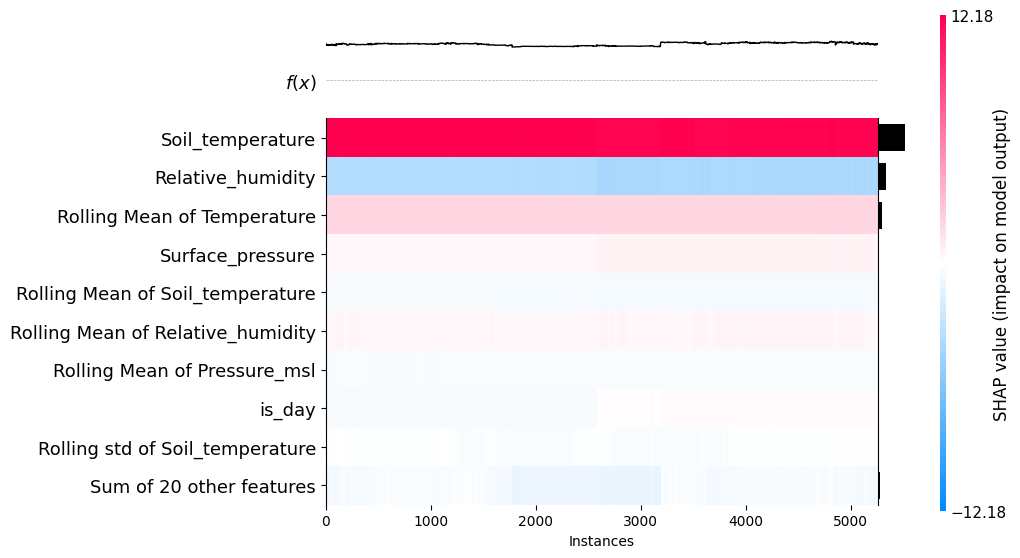

<Axes: xlabel='Instances'>

In [39]:
shap.plots.heatmap(shap_values)

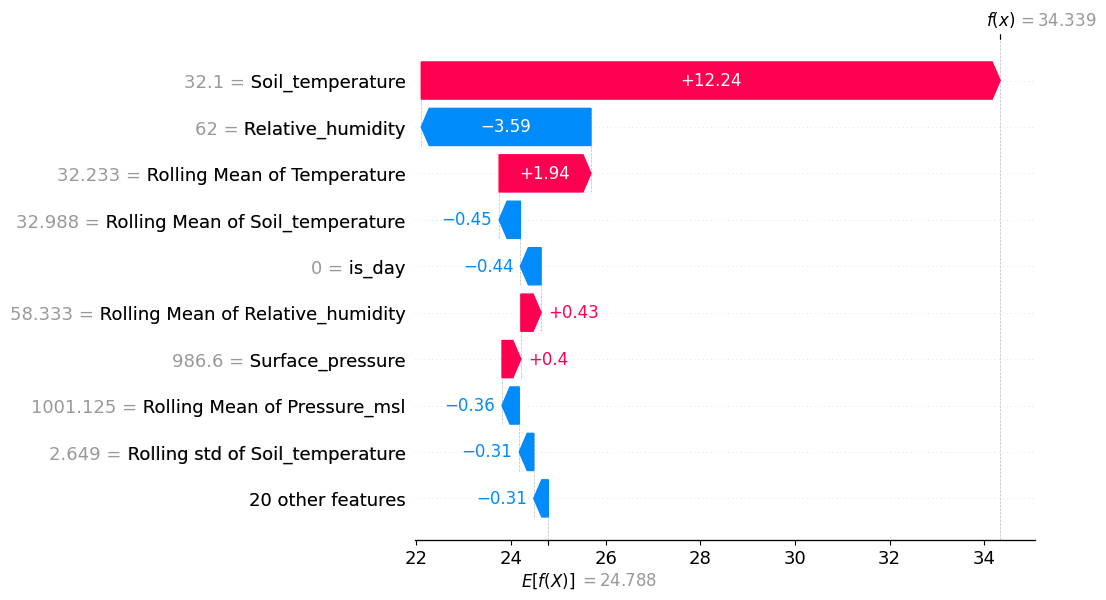

In [40]:
shap.plots.waterfall(shap_values[0])

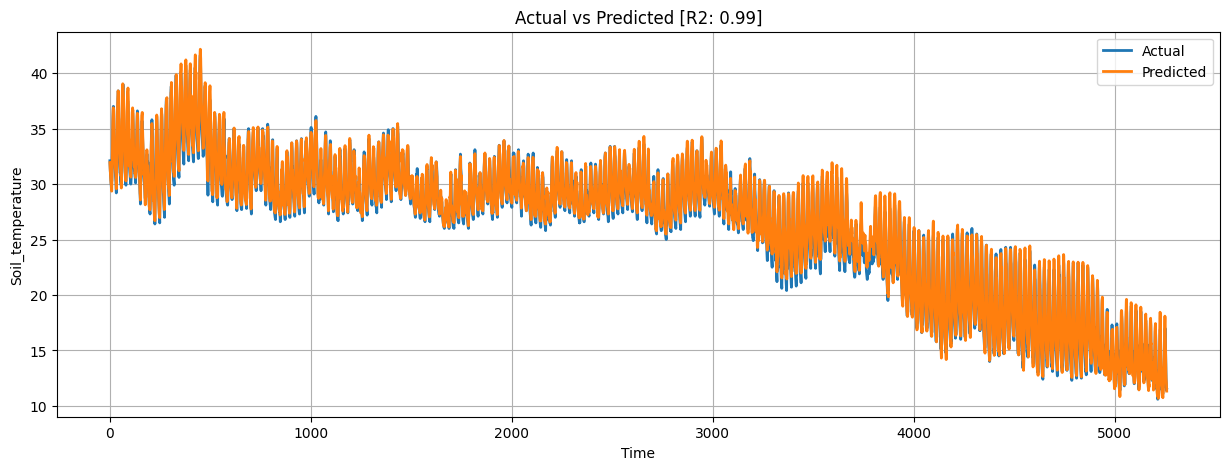

In [41]:
os.chdir("C:/Users/KISHORE/OneDrive/Desktop/Intelligent Weather Prediction Pipeline/models")
y_pred,y_test,mae,rmse,r2,model,X_train,target,X_test = evaluate_model("Soil_temperature")

plt.figure(figsize=(15,5))

plt.plot(y_test.values, label="Actual", linewidth=2)
plt.plot(y_pred, label="Predicted", linewidth=2)

plt.xlabel("Time")
plt.ylabel("Soil_temperature")
plt.title(f"Actual vs Predicted [R2: {round(r2,2)}]")
plt.legend()
plt.grid(True)

plt.show()


In [42]:
params = pd.DataFrame([model.get_params()])

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
})

eval_df = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R2"],
    "Value": [mae, rmse, r2]
})

merged = pd.concat([params, importance, eval_df], ignore_index=True)

os.chdir("C:/Users/KISHORE/OneDrive/Desktop/Intelligent Weather Prediction Pipeline/models/model_summaries")
merged.to_excel(f"{target} Model Summary.xlsx",index = False)

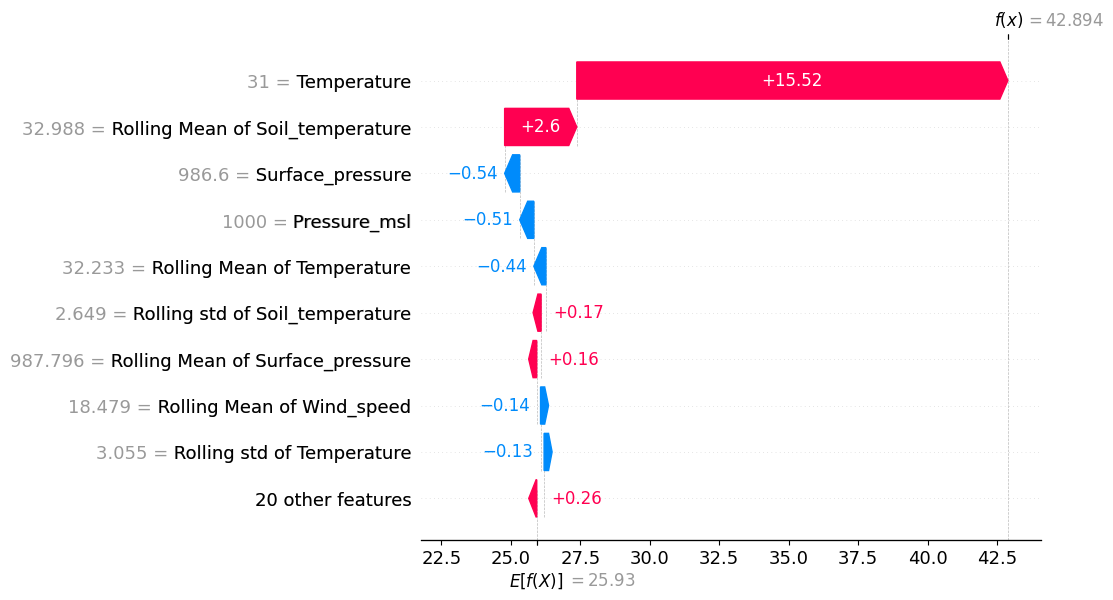

In [43]:
explainer = shap.Explainer(model)
shap_values = explainer(X_test)

shap.plots.waterfall(shap_values[0])

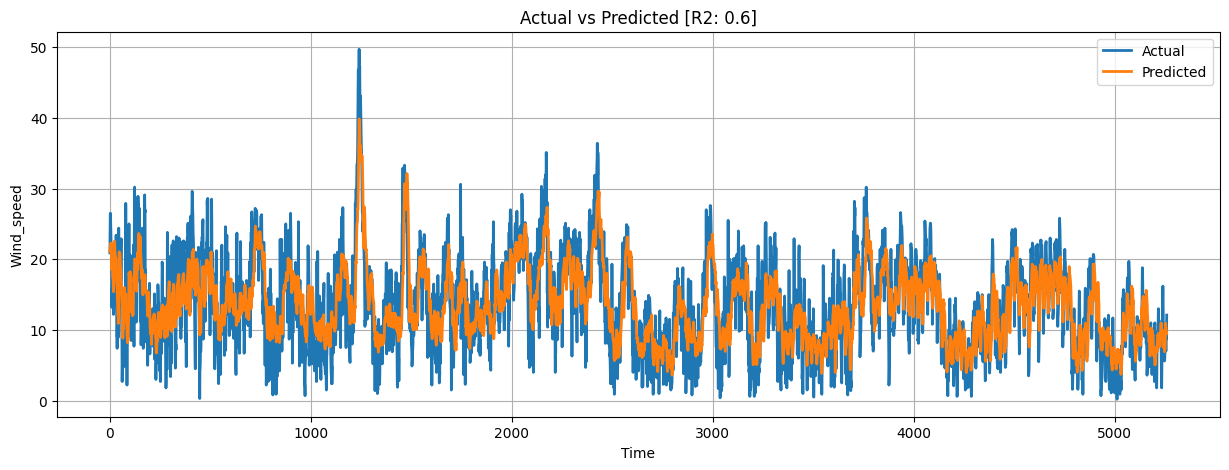

In [44]:
os.chdir("C:/Users/KISHORE/OneDrive/Desktop/Intelligent Weather Prediction Pipeline/models")
y_pred,y_test,mae,rmse,r2,model,X_train,target,X_test = evaluate_model("Wind_speed")

plt.figure(figsize=(15,5))

plt.plot(y_test.values, label="Actual", linewidth=2)
plt.plot(y_pred, label="Predicted", linewidth=2)

plt.xlabel("Time")
plt.ylabel("Wind_speed")
plt.title(f"Actual vs Predicted [R2: {round(r2,2)}]")
plt.legend()
plt.grid(True)

plt.show()

In [45]:
params = pd.DataFrame([model.get_params()])

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
})

eval_df = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R2"],
    "Value": [mae, rmse, r2]
})

merged = pd.concat([params, importance, eval_df], ignore_index=True)

os.chdir("C:/Users/KISHORE/OneDrive/Desktop/Intelligent Weather Prediction Pipeline/models/model_summaries")
merged.to_excel(f"{target} Model Summary.xlsx",index = False)

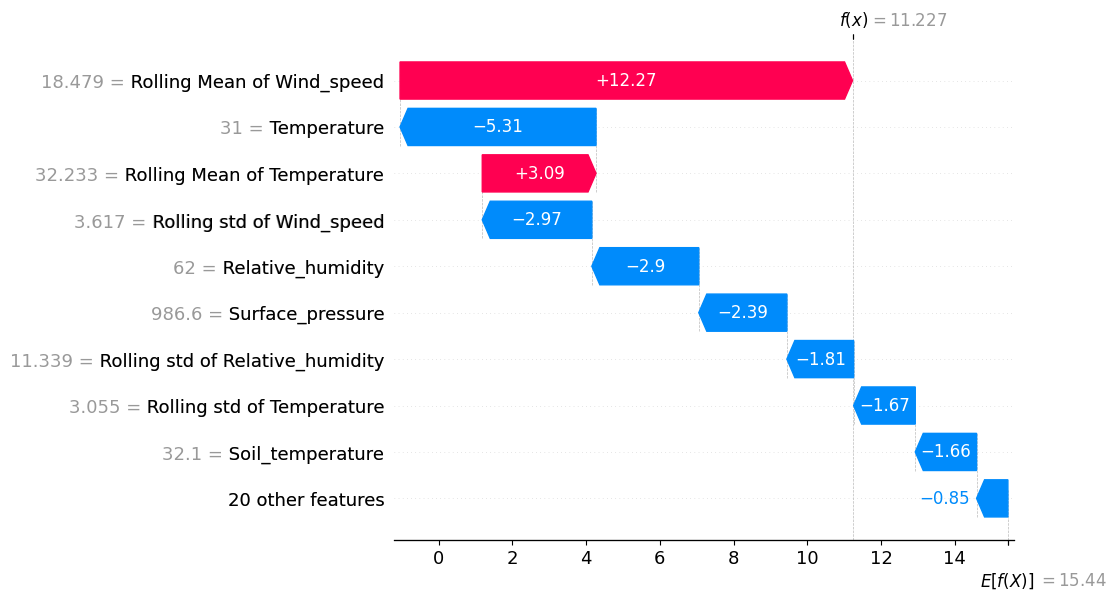

In [46]:
explainer = shap.Explainer(model)
shap_values = explainer(X_test)

shap.plots.waterfall(shap_values[0])

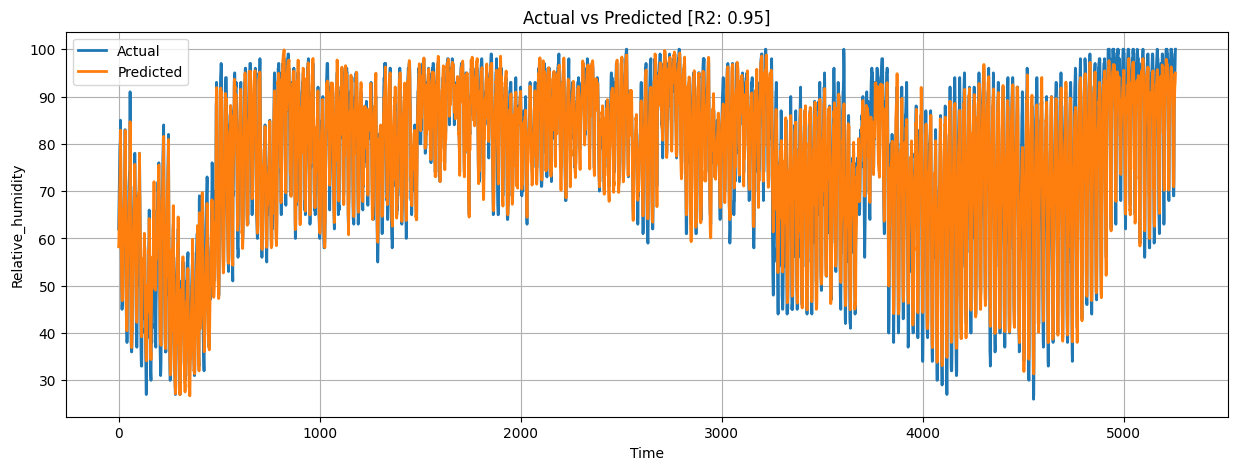

In [47]:
os.chdir("C:/Users/KISHORE/OneDrive/Desktop/Intelligent Weather Prediction Pipeline/models")
y_pred,y_test,mae,rmse,r2,model,X_train,target,X_test = evaluate_model("Relative_humidity")

plt.figure(figsize=(15,5))

plt.plot(y_test.values, label="Actual", linewidth=2)
plt.plot(y_pred, label="Predicted", linewidth=2)

plt.xlabel("Time")
plt.ylabel("Relative_humidity")
plt.title(f"Actual vs Predicted [R2: {round(r2,2)}]")
plt.legend()
plt.grid(True)

plt.show()

In [48]:
params = pd.DataFrame([model.get_params()])

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
})

eval_df = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R2"],
    "Value": [mae, rmse, r2]
})

merged = pd.concat([params, importance, eval_df], ignore_index=True)

os.chdir("C:/Users/KISHORE/OneDrive/Desktop/Intelligent Weather Prediction Pipeline/models/model_summaries")
merged.to_excel(f"{target} Model Summary.xlsx",index = False)

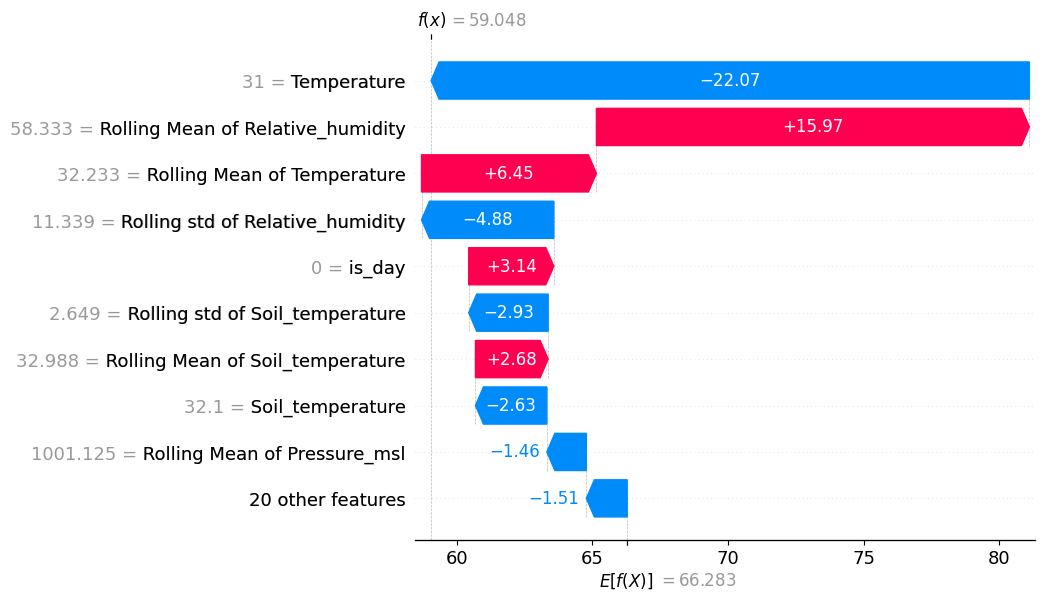

In [49]:
explainer = shap.Explainer(model)
shap_values = explainer(X_test)

shap.plots.waterfall(shap_values[0])

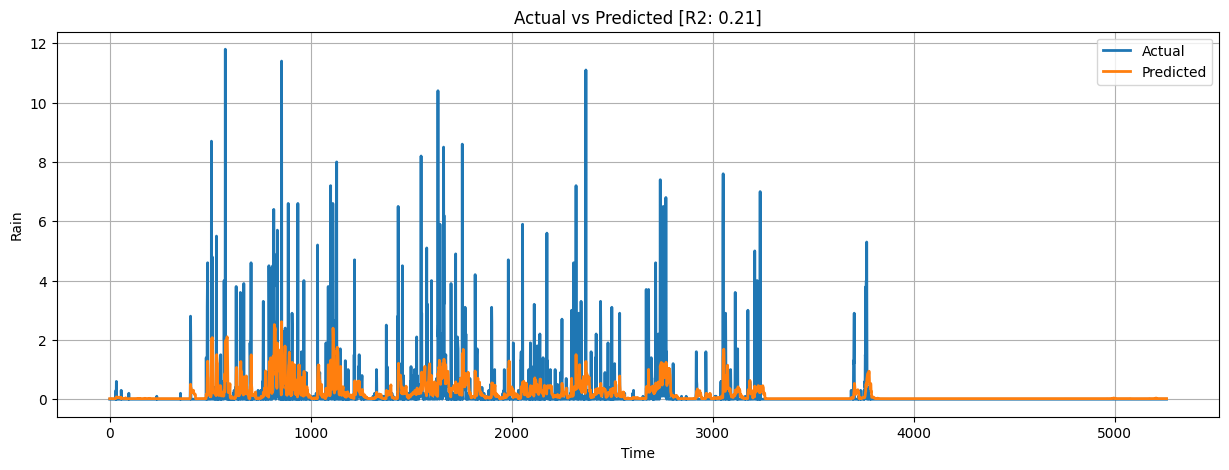

In [50]:
os.chdir("C:/Users/KISHORE/OneDrive/Desktop/Intelligent Weather Prediction Pipeline/models")
y_pred,y_test,mae,rmse,r2,model,X_train,target,X_test = evaluate_model("Rain")

plt.figure(figsize=(15,5))

plt.plot(y_test.values, label="Actual", linewidth=2)
plt.plot(y_pred, label="Predicted", linewidth=2)

plt.xlabel("Time")
plt.ylabel("Rain")
plt.title(f"Actual vs Predicted [R2: {round(r2,2)}]")
plt.legend()
plt.grid(True)

plt.show()

In [51]:
params = pd.DataFrame([model.get_params()])

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
})

eval_df = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R2"],
    "Value": [mae, rmse, r2]
})

merged = pd.concat([params, importance, eval_df], ignore_index=True)

os.chdir("C:/Users/KISHORE/OneDrive/Desktop/Intelligent Weather Prediction Pipeline/models/model_summaries")
merged.to_excel(f"{target} Model Summary.xlsx",index = False)

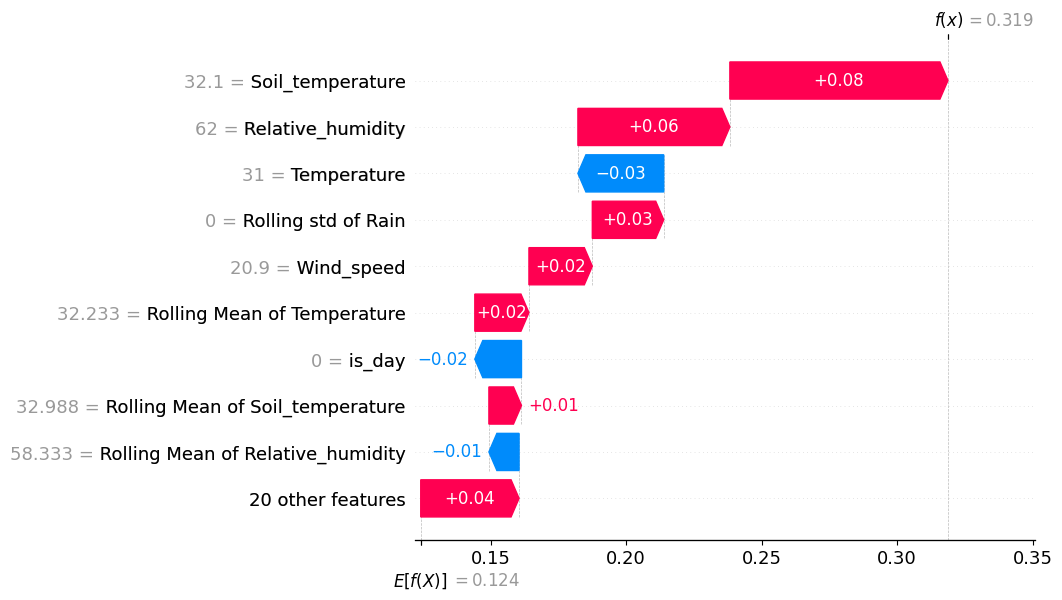

In [52]:
explainer = shap.Explainer(model)
shap_values = explainer(X_test)

shap.plots.waterfall(shap_values[0])

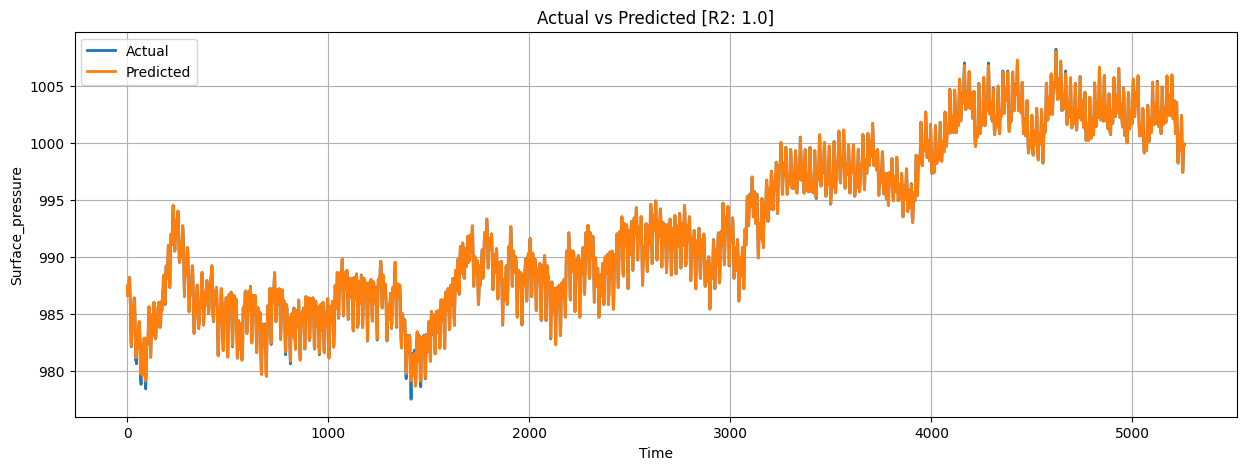

In [53]:
os.chdir("C:/Users/KISHORE/OneDrive/Desktop/Intelligent Weather Prediction Pipeline/models")
y_pred,y_test,mae,rmse,r2,model,X_train,target,X_test = evaluate_model("Surface_pressure")

plt.figure(figsize=(15,5))

plt.plot(y_test.values, label="Actual", linewidth=2)
plt.plot(y_pred, label="Predicted", linewidth=2)

plt.xlabel("Time")
plt.ylabel("Surface_pressure")
plt.title(f"Actual vs Predicted [R2: {round(r2,2)}]")
plt.legend()
plt.grid(True)

plt.show()

In [54]:
params = pd.DataFrame([model.get_params()])

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
})

eval_df = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R2"],
    "Value": [mae, rmse, r2]
})

merged = pd.concat([params, importance, eval_df], ignore_index=True)

os.chdir("C:/Users/KISHORE/OneDrive/Desktop/Intelligent Weather Prediction Pipeline/models/model_summaries")
merged.to_excel(f"{target} Model Summary.xlsx",index = False)

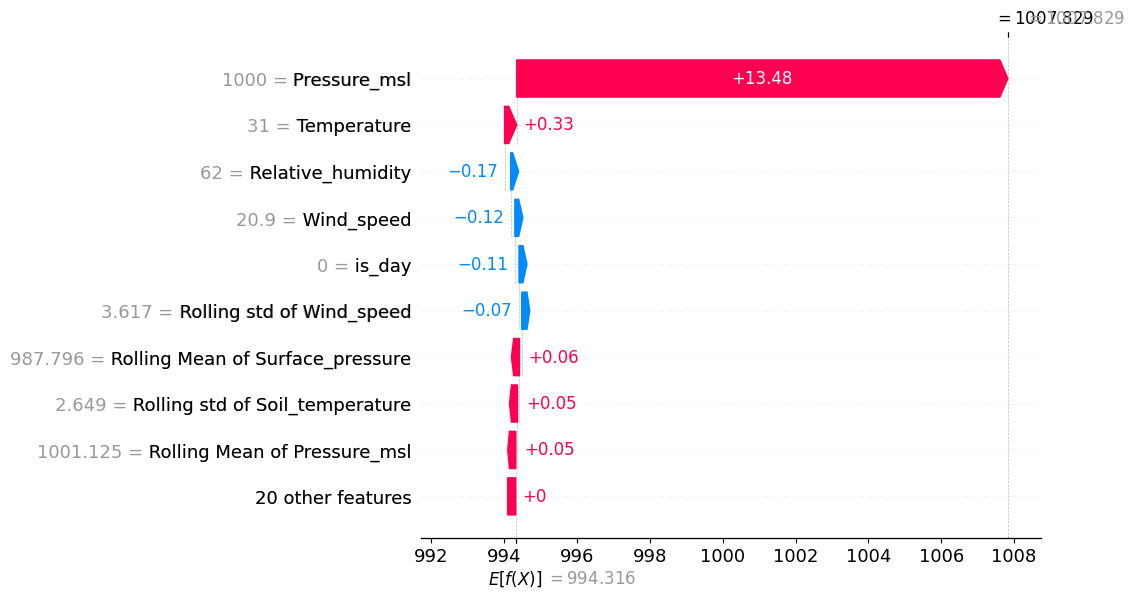

In [55]:
explainer = shap.Explainer(model)
shap_values = explainer(X_test)

shap.plots.waterfall(shap_values[0])

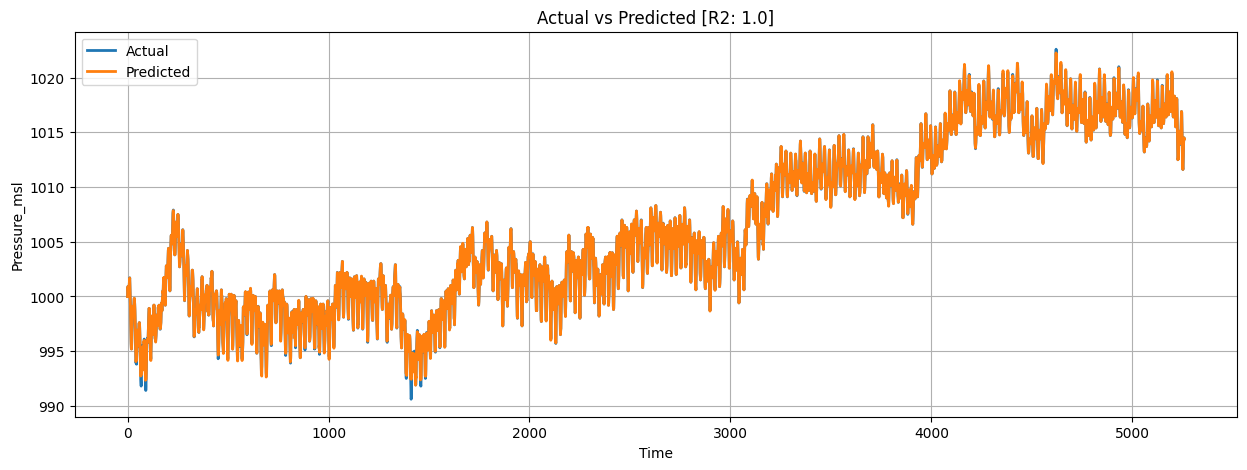

In [56]:
os.chdir("C:/Users/KISHORE/OneDrive/Desktop/Intelligent Weather Prediction Pipeline/models")
y_pred,y_test,mae,rmse,r2,model,X_train,target,X_test = evaluate_model("Pressure_msl")

plt.figure(figsize=(15,5))

plt.plot(y_test.values, label="Actual", linewidth=2)
plt.plot(y_pred, label="Predicted", linewidth=2)

plt.xlabel("Time")
plt.ylabel("Pressure_msl")
plt.title(f"Actual vs Predicted [R2: {round(r2,2)}]")
plt.legend()
plt.grid(True)

plt.show()

In [57]:
params = pd.DataFrame([model.get_params()])

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
})

eval_df = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R2"],
    "Value": [mae, rmse, r2]
})

merged = pd.concat([params, importance, eval_df], ignore_index=True)

os.chdir("C:/Users/KISHORE/OneDrive/Desktop/Intelligent Weather Prediction Pipeline/models/model_summaries")
merged.to_excel(f"{target} Model Summary.xlsx",index = False)

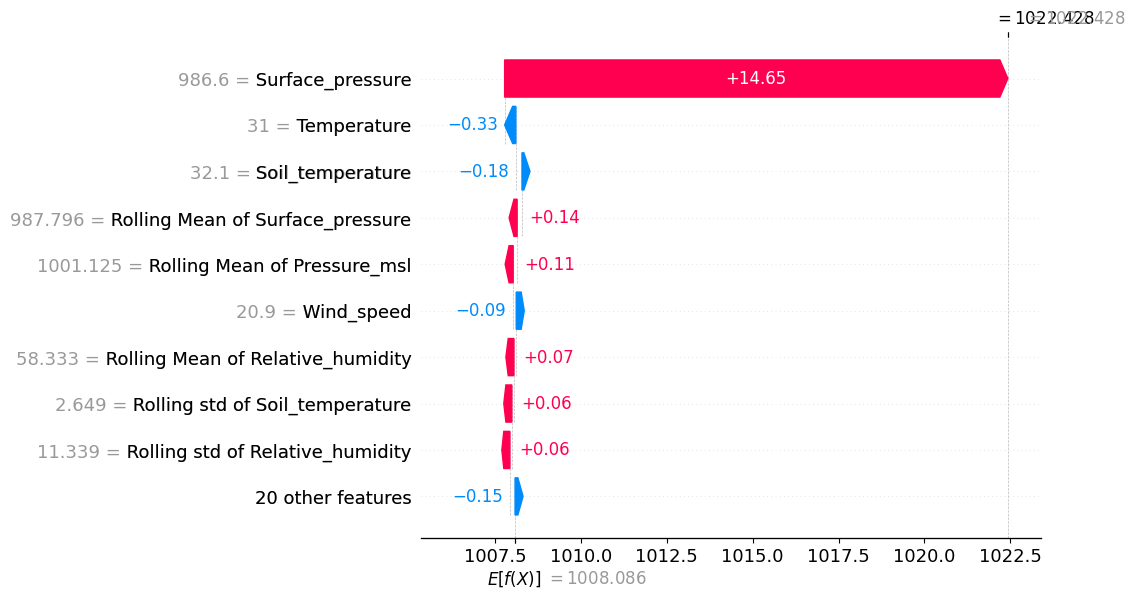

In [58]:
explainer = shap.Explainer(model)
shap_values = explainer(X_test)

shap.plots.waterfall(shap_values[0])

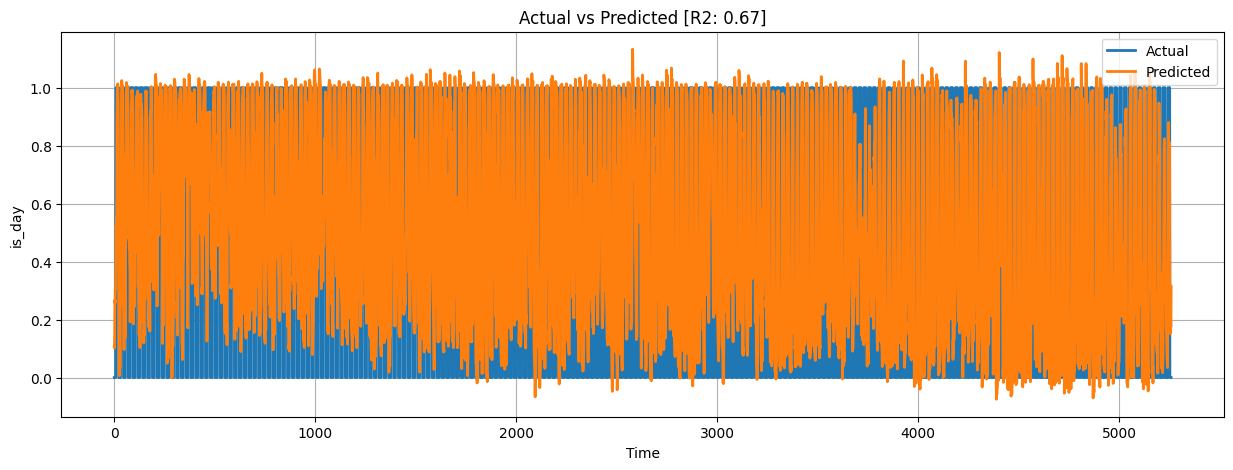

In [59]:
os.chdir("C:/Users/KISHORE/OneDrive/Desktop/Intelligent Weather Prediction Pipeline/models")

y_pred,y_test,mae,rmse,r2,model,X_train,target,X_test = evaluate_model("is_day")

plt.figure(figsize=(15,5))

plt.plot(y_test.values, label="Actual", linewidth=2)
plt.plot(y_pred, label="Predicted", linewidth=2)

plt.xlabel("Time")
plt.ylabel("is_day")
plt.title(f"Actual vs Predicted [R2: {round(r2,2)}]")
plt.legend()
plt.grid(True)

plt.show()

In [60]:
params = pd.DataFrame([model.get_params()])

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
})

eval_df = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R2"],
    "Value": [mae, rmse, r2]
})

merged = pd.concat([params, importance, eval_df], ignore_index=True)

os.chdir("C:/Users/KISHORE/OneDrive/Desktop/Intelligent Weather Prediction Pipeline/models/model_summaries")
merged.to_excel(f"{target} Model Summary.xlsx",index = False)

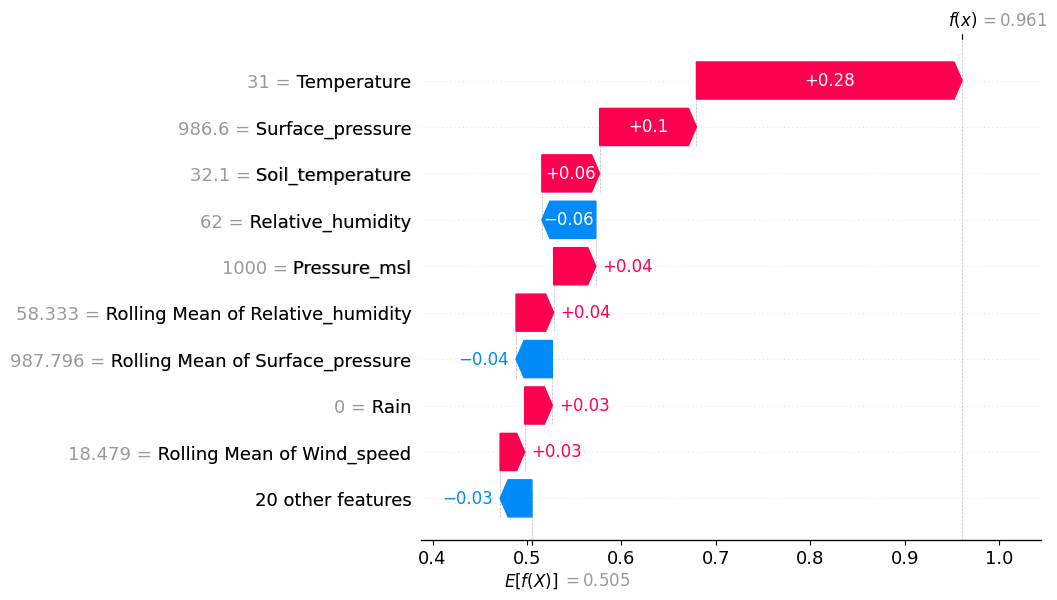

In [61]:
explainer = shap.Explainer(model)
shap_values = explainer(X_test)

shap.plots.waterfall(shap_values[0])

In [62]:
weather_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 52585 entries, 2020-01-01 23:00:00 to 2025-12-31 23:00:00
Data columns (total 30 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Temperature                        52585 non-null  float64
 1   Relative_humidity                  52585 non-null  int64  
 2   Rain                               52585 non-null  float64
 3   Soil_temperature                   52585 non-null  float64
 4   Wind_speed                         52585 non-null  float64
 5   Surface_pressure                   52585 non-null  float64
 6   Pressure_msl                       52585 non-null  float64
 7   is_day                             52585 non-null  int64  
 8   Rolling Mean of Temperature        52585 non-null  float64
 9   Rolling Mean of Relative_humidity  52585 non-null  float64
 10  Rolling Mean of Rain               52585 non-null  float64
 11  Rolling Mean of Soi

In [63]:
mae

0.19426807761192322

In [ ]:
target = "Temperature"
X_train = train_data.drop(columns=[target])
y_train = train_data[target]

X_test = test_data.drop(columns=[target])
y_test = test_data[target]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



In [ ]:
with open(f'fine_{target}_xgb_model.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

In [ ]:
y_pred = loaded_model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

In [ ]:
mae

In [ ]:
rmse

In [ ]:
r2

In [ ]:
y_pred

In [ ]:
plt.figure(figsize=(15,5))

plt.plot(y_test.values, label="Actual", linewidth=2)
plt.plot(y_pred, label="Predicted", linewidth=2)

plt.xlabel("Time")
plt.ylabel("Temperature")
plt.title("Actual vs Predicted")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler

target = "Temperature"
X_train = train_data.drop(columns=[target])
y_train = train_data[target]

X_test = test_data.drop(columns=[target])
y_test = test_data[target]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

param_dist = {
                'n_estimators': [100, 200, 300, 500, 800],
                'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2],
                'max_depth': [3, 4, 5, 6, 8, 10],
                'min_child_weight': [1, 3, 5, 7],
                'subsample': [0.6, 0.8, 1.0],
                'colsample_bytree': [0.6, 0.8, 1.0],
                'gamma': [0, 0.1, 0.3, 0.5],
                'reg_alpha': [0, 0.01, 0.1, 1],
                'reg_lambda': [1, 2, 5, 10]
            } 


def finetune_model(model,param_dist,X_train_scaled,y_train):

                rm_search = RandomizedSearchCV(
                    estimator=model,
                    param_distributions=param_dist,
                    n_iter=50,
                    scoring='neg_root_mean_squared_error',
                    cv=5,
                    verbose=2,
                    random_state=42,
                    n_jobs=-1
                )

                rm_search.fit(X_train_scaled,y_train)

                return rm_search.best_estimator_

In [ ]:
os.chdir("C:/Users/KISHORE/OneDrive/Desktop/Intelligent Weather Prediction Pipeline/models")

with open('Temperature_xgb_model.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

temper_model = finetune_model(loaded_model,param_dist,X_train_scaled,y_train)

In [ ]:
temper_model

In [ ]:
pred = temper_model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

In [ ]:
mae

In [ ]:
rmse

In [ ]:
r2

In [ ]:
with open('Temperature_xgb_model_fin.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

results = []

for target in weather_data.columns:

    X_train = train_data.drop(columns=[target])
    y_train = train_data[target]

    X_test = test_data.drop(columns=[target])
    y_test = test_data[target]

    model = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        random_state=42
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    results.append([target, mae, rmse, r2])

evaluation = pd.DataFrame(
    results,
    columns=["Target", "MAE", "RMSE", "R²"]
)

print(evaluation)

In [ ]:
import pandas as pd
import numpy as np

from lightgbm import LGBMRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

results = []

for target in weather_data.columns:

    X_train = train_data.drop(columns=[target])
    y_train = train_data[target]

    X_test = test_data.drop(columns=[target])
    y_test = test_data[target]

    model = LGBMRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        random_state=42
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    results.append([target, mae, rmse, r2])

evaluation = pd.DataFrame(
    results,
    columns=["Target", "MAE", "RMSE", "R²"]
)

print(evaluation)